In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [3]:
df = pd.read_csv(r"E:\engg\Data\iris_flower_data\IRIS.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB


In [30]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [31]:
df.reset_index(drop=True, inplace=True)

In [12]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [32]:
df["species"].value_counts()

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='species'>

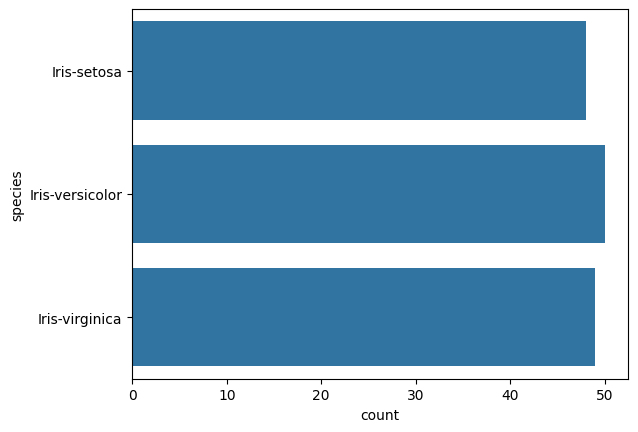

In [33]:
sns.countplot(df["species"])

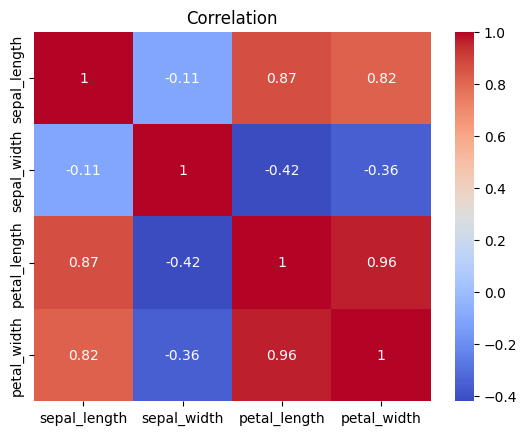

In [34]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title('Correlation')
plt.show()

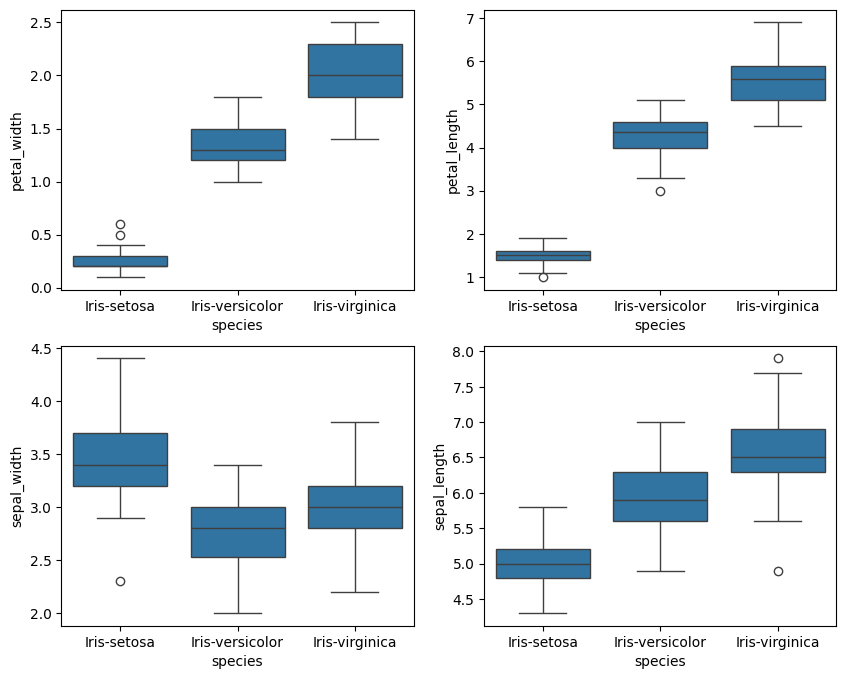

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))
sns.boxplot(data=df, x="species", y="petal_width", ax=ax[0,0])
sns.boxplot(data=df, x="species", y="petal_length", ax=ax[0,1])
sns.boxplot(data=df, x="species", y="sepal_width", ax=ax[1,0])
sns.boxplot(data=df, x="species", y="sepal_length", ax=ax[1,1])
plt.show()

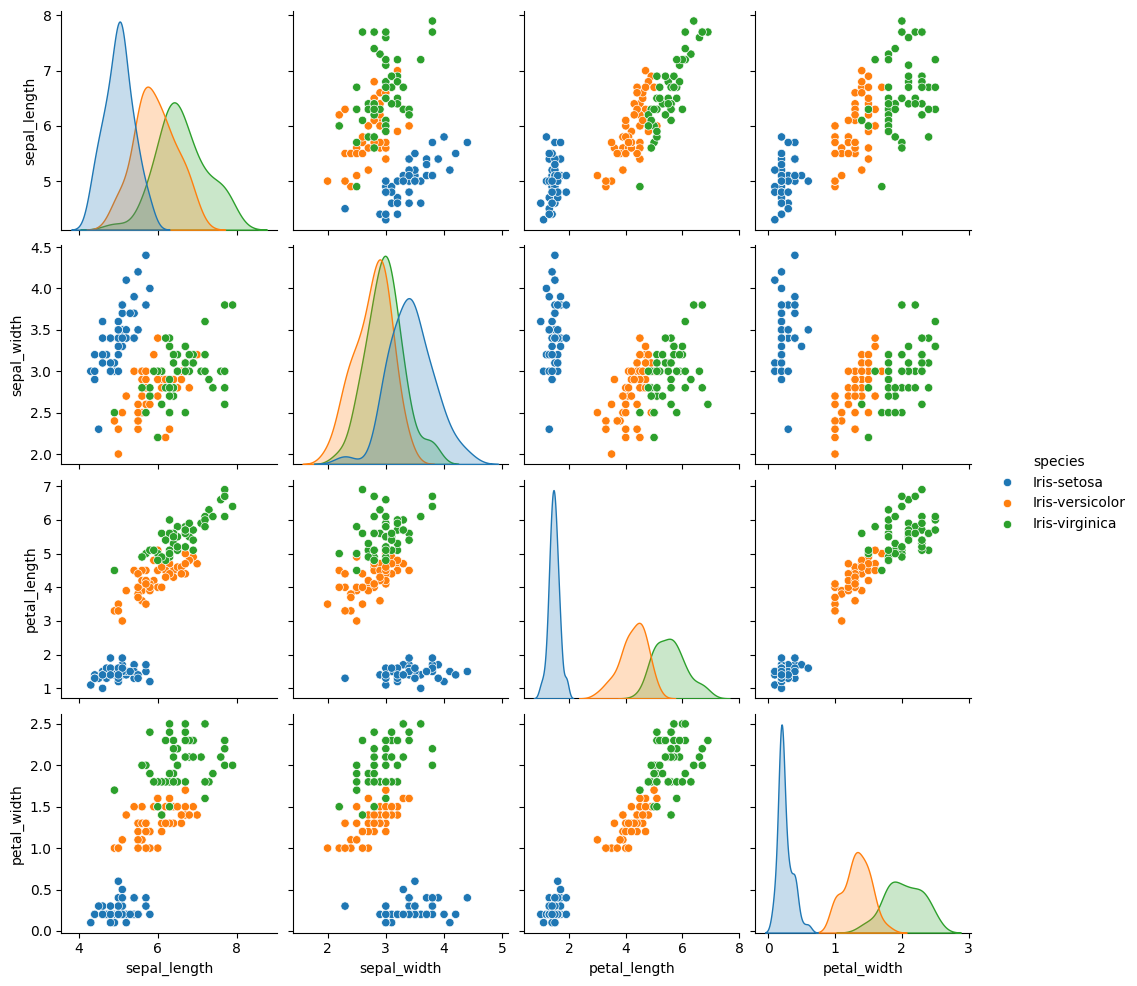

In [36]:
sns.pairplot(df, hue="species")
plt.show()

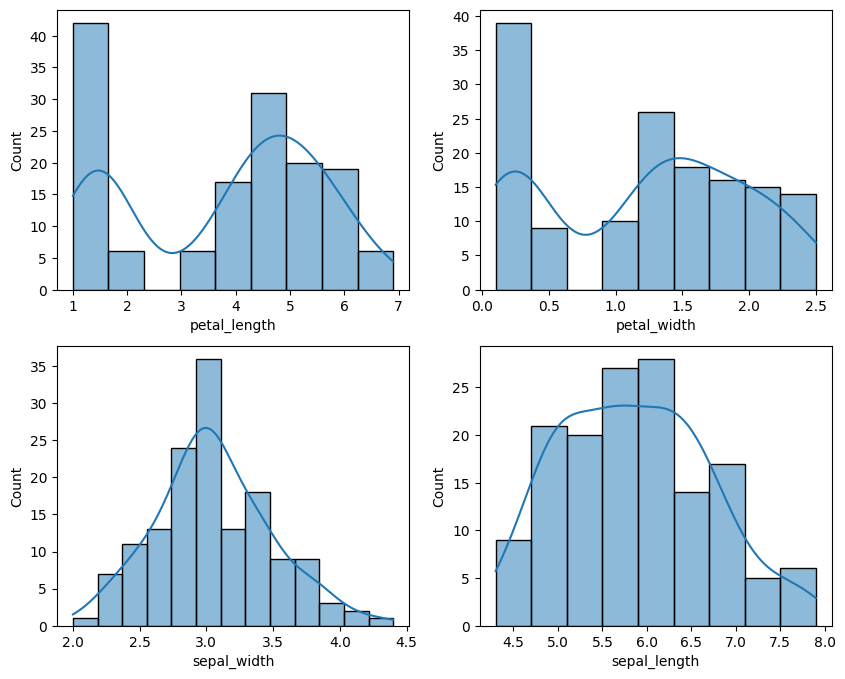

In [37]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))
sns.histplot(df["petal_length"], kde=True, ax=ax[0,0])
sns.histplot(df["petal_width"], kde=True, ax=ax[0,1])
sns.histplot(df["sepal_width"], kde=True, ax=ax[1,0])
sns.histplot(df["sepal_length"], kde=True, ax=ax[1,1])
plt.show()

### Model-

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, f1_score, precision_score

In [43]:
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [45]:
df['species'].value_counts()

species
1    50
2    49
0    48
Name: count, dtype: int64

In [46]:
x = df.drop('species', axis=1)
y = df["species"]

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [58]:
lr= LogisticRegression(max_iter=100,random_state=42)
svc = SVC(kernel='linear')
rf= RandomForestClassifier(n_estimators=100, random_state=42)

In [59]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [60]:
svc.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [61]:
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred_LR = lr.predict(x_test)
y_pred_SVC = svc.predict(x_test)
y_pred_RF = rf.predict(x_test)

In [63]:
results = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest", "SVC"],
    "Accuracy": [accuracy_score(y_test, y_pred_LR),accuracy_score(y_test, y_pred_RF),accuracy_score(y_test, y_pred_SVC)],
    "Precision": [precision_score(y_test, y_pred_LR, average='weighted'),precision_score(y_test, y_pred_RF, average='weighted'),precision_score(y_test, y_pred_SVC, average='weighted')],
    "Recall": [recall_score(y_test, y_pred_LR, average='weighted'),recall_score(y_test, y_pred_RF, average='weighted'),recall_score(y_test, y_pred_SVC, average='weighted')],
    "F1-Score": [f1_score(y_test, y_pred_LR, average='weighted'),f1_score(y_test, y_pred_RF, average='weighted'),f1_score(y_test, y_pred_SVC, average='weighted')]
})
results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,Random Forest,0.933333,0.933333,0.933333,0.933333
2,SVC,0.966667,0.970000,0.966667,0.966667


In [64]:
print("Logistic Regression -")
print(confusion_matrix(y_test, y_pred_LR))

print("Random Forest-")
print(confusion_matrix(y_test, y_pred_RF))

print("SVC -")
print(confusion_matrix(y_test, y_pred_SVC))

Logistic Regression -
[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]
Random Forest-
[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]
SVC -
[[11  0  0]
 [ 0  9  1]
 [ 0  0  9]]


In [65]:
with open ("iris.pkl",'wb') as fh:
    pickle.dump(svc ,fh)